![LogoUC3M](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg/320px-Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg.png)

# 2DA PRACTICA - DETERMINACIÓN DE TIPOS DE ESTRELLAS

### **Grupo 82 - Equipo 15**

*   Ariana Cornejo Infante,     100522121, 100522121@alumnos.uc3m.es
*   Francisco Pérez Sokolowski, 100522254, 100522254@alumnos.uc3m.es

El objetivo es aplicar técnicas de **aprendizaje no supervisado** para detectar agrupaciones naturales de estrellas. Se cuenta con la información física de 240 estrellas en el fichero `stars_data.csv` que contiene las siguientes variables:

- Temperature → temperatura superficial (Kelvin)
- L → luminosidad relativa al Sol
- R → radio relativo al Sol
- A_M → magnitud absoluta
- Color → color dominante del espectro
- Spectral_Class → clase espectral



In [12]:
# --- IMPORTACIONES NECESARIAS ---
# Instalamos DBCV directamente desde el repositorio de GitHub
!pip install git+https://github.com/FelSiq/DBCV.git

import dbcv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

# Fijar semilla (usando el NIA) para reproducibilidad
SEED = 100522121
np.random.seed(SEED)

  Cloning https://github.com/FelSiq/DBCV.git to /tmp/pip-req-build-_0eiqmhp
  Running command git clone --filter=blob:none --quiet https://github.com/FelSiq/DBCV.git /tmp/pip-req-build-_0eiqmhp
  Resolved https://github.com/FelSiq/DBCV.git to commit 13c3896ef78d12f1e3e1cbd394f2db9a09637ffd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Análisis exploratorio inicial

Antes de aplicar cualquier técnica de clustering:

1. Revisamos estructura del dataset
2. Detectamos valores nulos
3. Observamos estadísticas básicas

In [13]:
# Carga del dataset del fichero stars_data.csv
df = pd.read_csv("https://github.com/100522254/Proyecto-ML-2/raw/main/stars_data.csv")
df.head()

df.info()
df.describe()     # resumen estadístico de las variables
df.isnull().sum() # cuenta los valores nulos en cada columna del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


,0
Temperature,0
L,0
R,0
A_M,0
Color,0
Spectral_Class,0


### 1.1. Codificación ordinal de variables categóricas

Las variables categóricas **Color** y **Spectral_Class** deben codificarse ordinalmente porque contienen información física relacionada con la temperatura y energía de la estrella. Asignamos valores numéricos manteniendo el orden físico según la clase espectral: ***O > B > A > F > G > K > M***

In [14]:
# Para ver los valores únicos y poder codificarlos posteriormente
df["Color"] = df["Color"].str.strip()
df["Spectral_Class"] = df["Spectral_Class"].str.strip()
print(df["Color"].unique())
print(df["Spectral_Class"].unique())

# Codificación ordinal
spectral_order = {
    "O": 6,
    "B": 5,
    "A": 4,
    "F": 3,
    "G": 2,
    "K": 1,
    "M": 0
}

df["Spectral_Class"] = df["Spectral_Class"].map(spectral_order)

# Codificación del color, el orden físico típico es:
# Red → Orange → Yellow → White → Blue-white → Blue
color_order = {
    "Red": 0,
    "Orange": 1,
    "Orange-Red": 0,
    "Pale yellow orange": 1,

    "Yellow": 2,
    "yellowish": 2,
    "Yellowish": 2,

    "Yellow-White": 3,
    "yellow-white": 3,
    "Yellowish White": 3,
    "White-Yellow": 3,

    "White": 4,
    "white": 4,
    "Whitish": 4,

    "Blue-White": 5,
    "Blue white": 5,
    "Blue White": 5,
    "Blue-white": 5,

    "Blue": 6
}

df["Color"] = df["Color"].map(color_order)

df.isnull().sum()

['Red' 'Blue White' 'White' 'Yellowish White' 'Blue white'
 'Pale yellow orange' 'Blue' 'Blue-white' 'Whitish' 'yellow-white'
 'Orange' 'White-Yellow' 'white' 'yellowish' 'Yellowish' 'Orange-Red'
 'Blue-White']
['M' 'B' 'A' 'F' 'O' 'K' 'G']


,0
Temperature,0
L,0
R,0
A_M,0
Color,0
Spectral_Class,0


### 1.2. Normalización de variables

Antes de aplicar PCA es necesario escalar las variables porque tienen diferentes unidades físicas:

- temperatura (Kelvin)
- radio solar relativo
- luminosidad relativa
- magnitud absoluta

Se utiliza **StandardScaler**, que transforma los datos con media 0 y desviación estándar 1.

In [15]:
# Normalizar variables con StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

## 2. Reducción de dimensionalidad mediante PCA

Para facilitar la visualización y mejorar el clustering, reducimos la dimensionalidad a 2 componentes principales. PCA permite:

- eliminar redundancia
- conservar máxima varianza
- facilitar representación visual

Varianza explicada: [0.55767031 0.29563497]


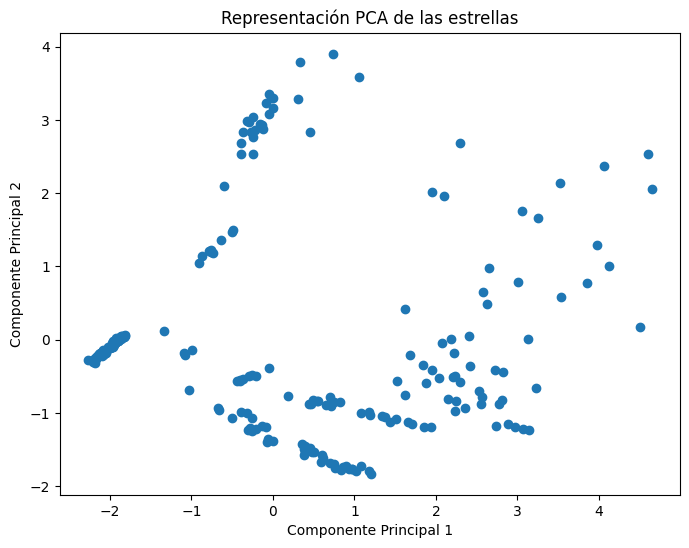

In [16]:
# --- APLICACIÓN DE PCA ---
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)  # transforma los datos escalados al nuevo espacio PCA
print("Varianza explicada:", pca.explained_variance_ratio_)

# --- VISUALIZACIÓN DE PCA ---
plt.figure(figsize=(8,6))            # crea la figura para representar los datos en 2D
plt.scatter(X_pca[:,0], X_pca[:,1])  # representa los datos proyectados en dos componentes

plt.title("Representación PCA de las estrellas")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## 3. Aplicación de tres algoritmos de clustering
### 3.1. Aplicación del algoritmo K-Means

*   **Selección del número óptimo de clusters (Método del codo)**

Permite estimar el número óptimo de clusters observando la inercia dentro del cluster.
Aplicamos K-Means usando el número de clusters obtenido con el método del codo.

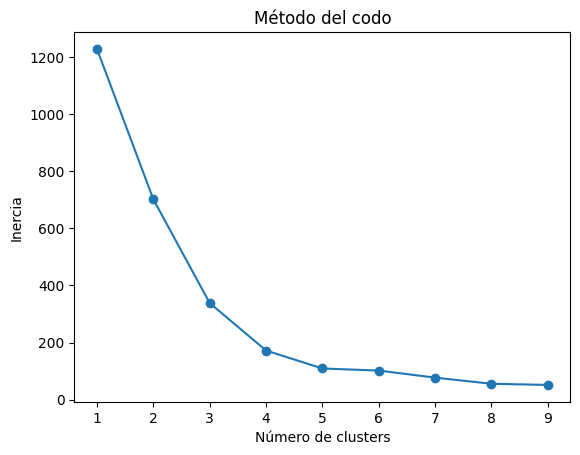

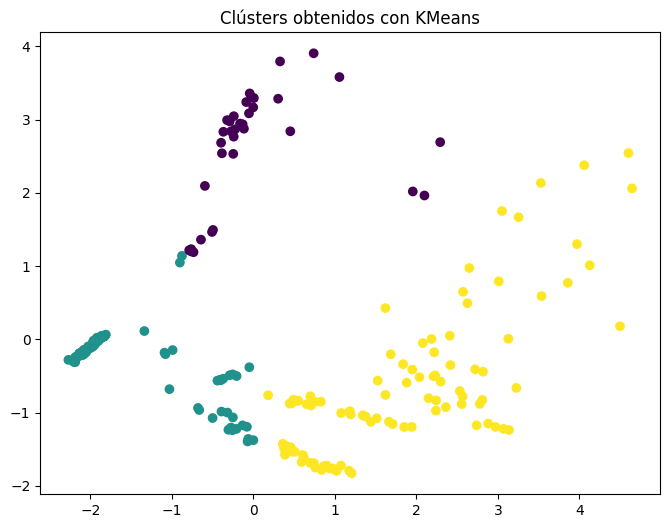

In [17]:
# --- MÉTODO DEL CODO ---
inertia = []

# Modelo KMeans con k clusters
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=SEED)
    kmeans.fit(X_pca)                # ajuste del modelo a datos reducidos (PCA)
    inertia.append(kmeans.inertia_)  # guardado de la inercia para cada k

# Visualización del método del codo
plt.plot(range(1,10), inertia, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

# Aplicar kmeans con el número óptimo de clusters
kmeans = KMeans(n_clusters=3, random_state=SEED)  # modelo con k=3
labels_kmeans = kmeans.fit_predict(X_pca)         # asignar clusters a cada punto

# --- VISUALIZACIÓN DE CLUSTERS ---
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_kmeans,
    cmap="viridis"
)

# Visualización final de clústers
plt.title("Clústers obtenidos con KMeans")
plt.show()

Se observa un codo pronunciado en k=3, a partir del cual la reducción de inercia es marginal, por lo cual se eligen 3 clusters.

*   **Evaluación del clustering mediante Silhouette Score**

El índice silhouette mide la cohesión interna y la separación entre clusters.

Valores cercanos a 1 indican clustering adecuado.

In [18]:
# --- CÁLCULO DEL SILHOUETTE SCORE ---
silhouette = silhouette_score(X_pca, labels_kmeans)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.5782128190918999


### 3.2. Clustering jerárquico aglomerativo

Aplicamos clustering jerárquico como alternativa a KMeans para comparar resultados. El criterio de enlace (linkage) es *ward*, ya que minimiza la varianza intraclúster, produciendo clusters más compactos y equilibrados.

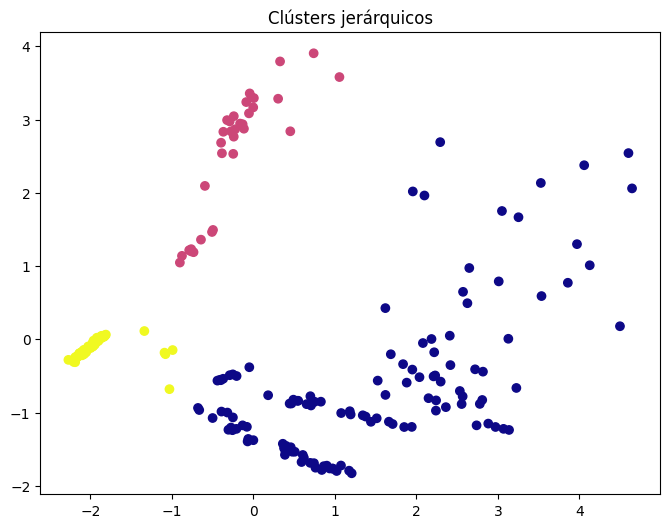

In [19]:
# --- CLUSTERING JERÁRQUICO AGLOMERATIVO ---
agglo = AgglomerativeClustering(n_clusters=3)  # número fijo de 3 clusters
labels_agglo = agglo.fit_predict(X_pca)

# --- VISUALIZACIÓN JERÁRQUICA AGLOMERATIVA ---
# Representar los datos en el espacio PCA, coloreando según el clúster asignado
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_agglo,  # color según el clúster asignado
    cmap="plasma"    # plasma es la paleta de colores
)

plt.title("Clústers jerárquicos")
plt.show()

### 3.3. DBSCAN

Aplicamos DBCV (Density Based Cluster Validation).
No usamos *Silhouette Score*, ya que asume que todos los puntos pertenecen a un cluster, y penaliza mucho las anomalías o ruido.
A continuación usaremos NearestNeighbors para calcular el radio eps ideal para nuestro algoritmo. De esta manera, calculamos distancias de cada punto a su $k$-ésimo vecino más cercano (donde $k$ suele ser nuestro min_samples).
Luego ordenamos las distancias y donde se forma una especie de "codo" pronunciado, estará nuestro valor de eps.

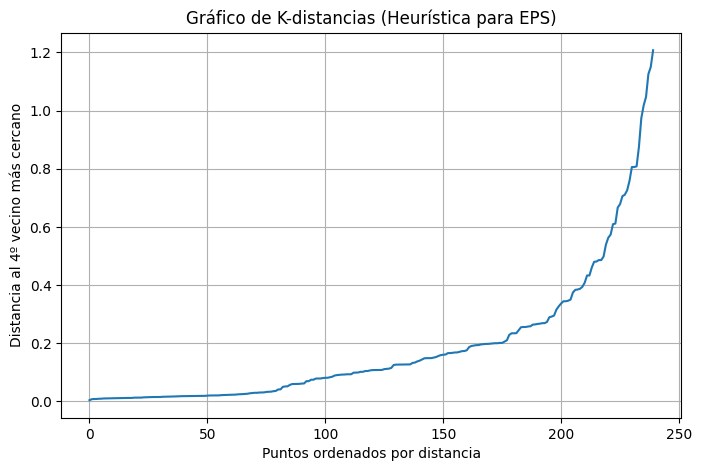

In [20]:
# Definir cuántos vecinos se quiere mirar. Para min_samples en DBSCAN: 2 * n_dimensiones
vecinos = 4  # como usamos PCA con 2 componentes, min_samples = 4.

# Entrenar un modelo para buscar los vecinos más cercanos de cada punto en nuestro PCA
nn = NearestNeighbors(n_neighbors=vecinos)
nn.fit(X_pca)

# Calcular las distancias a esos vecinos
distances, indices = nn.kneighbors(X_pca) # (distancia, qué punto es el vecino)

# Ordenar las distancias de menor a mayor. Se fija solo en la distancia al 4º vecino, por eso el [:, 3])
# El índice 0 es el propio punto, el 1 es el primer vecino... el 3 es el cuarto vecino (4-1=3)
distancias_ordenadas = np.sort(distances[:, 3])

# --- VISUALIZACIÓN DE K-DISTANCIAS ---
plt.figure(figsize=(8, 5))
plt.plot(distancias_ordenadas)

plt.title("Gráfico de K-distancias (Heurística para EPS)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel("Distancia al 4º vecino más cercano")
plt.grid(True)
plt.show()

Buscando los mejores hiperparámetros para DBSCAN...

Mejores hiperparámetros encontrados: {'eps': 0.3, 'min_samples': 6}
Mejor puntuación DBCV: 0.7336


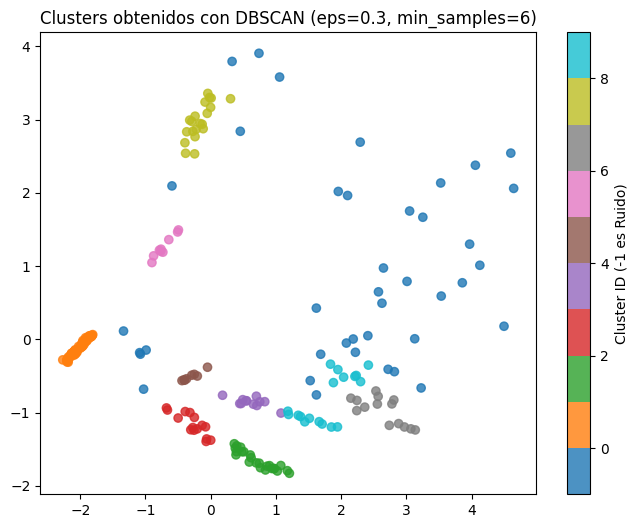

In [21]:
# Basándose en la heurística (el gráfico), definir un rango de valores para probar
eps_valores = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_valores = [3, 4, 5, 6]

mejor_dbcv = -2 # DBCV va de -1 a 1, inicializamos con un valor muy bajo
mejores_parametros_dbscan = {}
mejores_etiquetas_dbscan = None

print("Buscando los mejores hiperparámetros para DBSCAN...\n")

for eps in eps_valores:
    for min_samples in min_samples_valores:
        # Entrenar el modelo
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        etiquetas = dbscan.fit_predict(X_pca)

        # Contar cuántos clusters reales ha encontrado (ignorando el ruido, que es -1)
        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)

        # El DBCV necesita al menos 2 clusters válidos para poder comparar
        if n_clusters > 1:
            try:
                # Calcular la métrica DBCV
                score = dbcv.dbcv(X_pca, etiquetas)
                if score > mejor_dbcv:
                    mejor_dbcv = score  # guardamos el mejor resultado
                    mejores_parametros_dbscan = {'eps': eps, 'min_samples': min_samples}
                    mejores_etiquetas_dbscan = etiquetas

            # DBCV puede dar error si un cluster tiene pocos puntos o formas degeneradas
            except ValueError:
                continue

print(f"Mejores hiperparámetros encontrados: {mejores_parametros_dbscan}")
print(f"Mejor puntuación DBCV: {mejor_dbcv:.4f}")

# --- VISUALIZACIÓN DEL MEJOR DBSCAN ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=mejores_etiquetas_dbscan,
    cmap='tab10',  # mapa de colores 'tab10', pero los puntos de ruido (-1) en gris
    alpha=0.8
)
plt.title(f"Clusters obtenidos con DBSCAN (eps={mejores_parametros_dbscan['eps']}, min_samples={mejores_parametros_dbscan['min_samples']})")
plt.colorbar(label="Cluster ID (-1 es Ruido)")
plt.show()

Tras realizar la búsqueda de hiperparámetros, hemos seleccionado la configuración  $eps=0.3$ y $min$_$samples=6$. Esta combinación es la que arroja la puntuación DBCV más alta (0.7336), lo que sugiere que los grupos detectados son muy compactos y están bien separados entre sí. Además, con un radio de 0.3, el algoritmo detecta con precisión las estrellas que no encajan en ningún grupo (ruido), algo fundamental para no "contaminar" las categorías principales con datos atípicos.

### 3.4. Comparación y discusión de los 3 algoritmos

Los tres algoritmos de clustering aplicados presentan comportamientos distintos debido a sus supuestos sobre la estructura de los datos:

#### 3.4.1. K-Means

Está basado en centroides y asume que los clusters tienen forma aproximadamente esférica y similar tamaño. A partir del *método del codo*, se seleccionó $k=3$, lo que produce una partición clara y bien separada en el espacio reducido mediante PCA. Además, el *Silhouette Score* obtenido sugiere una adecuada cohesión interna y separación entre grupos.

* **Ventajas:** simplicidad, eficiencia computacional y estabilidad en los resultados.
* **Limitaciones:** es sensible a la inicialización de los centroides, no identifica ruido u outliers y presupone estructuras convexas, lo que puede no ajustarse a distribuciones más complejas.

#### 3.4.2. Clustering jerárquico (Aglomerativo)

Este construye los clusters de forma progresiva a partir de las distancias entre observaciones o grupos, sin necesidad de una inicialización aleatoria. Al fijar $n$_$clusters=3$, los resultados son en gran medida consistentes con los obtenidos mediante K-Means, aunque se observan ligeras diferencias en las fronteras de decisión debido al linkage utilizado.

* **Ventajas:** captura relaciones jerárquicas entre los datos, lo que puede aportar valor interpretativo.
* **Limitaciones:** es sensible a la elección del método de linkage, presenta menor escalabilidad y no gestiona adecuadamente la presencia de ruido (como K-Means).

#### 3.4.3. DBSCAN

Está basado en densidad que identifica clusters como regiones densas separadas por zonas de baja densidad. A diferencia de los anteriores, no requiere fijar el número de clusters, pero sí depende críticamente de los parámetros $eps$ y $min$_$samples$. La estimación de eps se ha guiado mediante el gráfico de K-distancias.

Además, se ha realizado una búsqueda de hiperparámetros, evaluando distintas combinaciones de eps y min_samples mediante la métrica DBCV (Density-Based Cluster Validation), más adecuada en este contexto al no penalizar la presencia de ruido. Como resultado, la mejor configuración encontrada ha sido $eps=0.3$, $min$_$samples=6$, $DBCV=0.7336$. Este valor elevado de DBCV indica que los clusters obtenidos son compactos y están bien separados, lo que valida la calidad de la partición encontrada por DBSCAN.

* **Ventajas:** detecta outliers de forma explícita y se adapta a clusters con formas arbitrarias, lo que resulta especialmente relevante en un contexto astronómico, donde pueden existir estrellas atípicas.
* **Limitaciones:** es muy sensible a la elección de parámetros y puede degradarse cuando existen diferencias significativas de densidad entre clusters. En datasets pequeños como este, también es frecuente que clasifique demasiados puntos como ruido o genere particiones menos estables.


En conclusión, **K-Means** y el **clustering jerárquico** producen resultados bastante similares y estables, mientras que **DBSCAN** permite identificar estructuras densas bien definidas y detectar outliers de forma explícita tras el ajuste de hiperparámetros, pudiendo detectar posibles estrellas atípicas.
No obstante, dado que el dataset parece tener una estructura relativamente compacta tras PCA, los métodos basados en distancia siguen ofreciendo particiones más claras y fácilmente interpretables.

## 4. Recomendación de pipeline, algoritmo e hiperparámetros

A partir de los resultados obtenidos y la discusión comparativa realizada en el punto anterior, procederemos a recomendar el siguiente pipeline de clustering y algoritmo con sus respectivos hiperparámetros.

### 4.1. Algoritmo recomendado: K-Means

Se recomienda **K-Means** como algoritmo final por las siguientes razones:

* Proporciona clusters bien definidos y fáciles de interpretar
* Presenta buen rendimiento según la métrica *Silhouette*
* Es consistente con la estructura observada en PCA
* Es más robusto y estable que DBSCAN en este dataset concreto
* Permite una correspondencia más directa con las clases físicas de estrellas


### 4.2. Hiperparámetros seleccionados

* **$n$_$clusters = 3$** fue determinado mediante el método del codo y representa un equilibrio entre simplicidad e interpretación física
* **$random$_$state = SEED$** debido a que garantiza reproducibilidad

### 4.3. Pipeline recomendado
1. Codificación ordinal de variables categóricas (`Color`, `Spectral_Class`) respetando su significado físico
2. Normalización con `StandardScaler`
3. Reducción de dimensionalidad con PCA (2 componentes)
4. Clustering con K-Means


### 4.4. Justificación final

El uso de PCA permite capturar la mayor parte de la varianza en solo dos dimensiones, facilitando la separación de los datos. Sobre este espacio reducido, K-Means logra una buena separación entre grupos y los clusters obtenidos son coherentes con posibles categorías físicas de estrellas (por ejemplo: estrellas frías vs calientes, gigantes vs enanas)

Aunque DBSCAN resulta útil para detectar outliers, no ofrece una estructura tan clara en este caso en particular. Por tanto, **K-Means con 3 clusters sobre los datos transformados mediante PCA** constituye la mejor elección para este problema.

